# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [12]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Fernando Emmanuel Perez Lopez"            # Tu nombre completo
MATRICULA = "81660"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "migracion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Fernando Emmanuel Perez Lopez
Matrícula: 81660
Dataset asignado: migracion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [13]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\ferch\Documents\Semestre5\BD-511\U1_1_probabilidad_estadistica\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: migracion
Descripcion: Numero total de inmigrantes internacionales residiendo en el pais (personas)


In [15]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [16]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,1990,57686,Asia
1,Afghanistan,AFG,1995,71522,Asia
2,Afghanistan,AFG,2000,75917,Asia
3,Afghanistan,AFG,2005,87314,Asia
4,Afghanistan,AFG,2010,102276,Asia
5,Afghanistan,AFG,2015,339432,Asia
6,Afghanistan,AFG,2020,144098,Asia
7,Afghanistan,AFG,2024,98110,Asia
8,Africa,OWID_AFR,1990,16176915,NaN
9,Africa,OWID_AFR,1995,16653698,NaN


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [17]:
# Forma del dataset (filas, columnas)
df.shape


(2144, 5)

In [18]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2144 entries, 0 to 2143
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   entity       2144 non-null   str  
 1   code         1960 non-null   str  
 2   year         2144 non-null   int64
 3   valor        2144 non-null   int64
 4   owid_region  1824 non-null   str  
dtypes: int64(2), str(3)
memory usage: 83.9 KB


In [19]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    2.144000e+03
mean     4.987920e+06
std      1.998549e+07
min      1.080000e+02
25%      3.905450e+04
50%      2.187635e+05
75%      1.420072e+06
max      3.040218e+08
Name: valor, dtype: float64

In [20]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           184
year             0
valor            0
owid_region    320
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*(Escribe aquí tu respuesta)*

Las variable principales que son valor y year son numéricas enteras y no tienen valores nulos. Los nulos se concentran exclusivamente code y owid_region, lo cual ocurre porque esos registros corresponden a agrupaciones o continentes que no tienen un código de país o región individual asignado.


## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [21]:
# Pregunta 1
# Tu codigo aqui

df_paises = df[df[config["filtro_paises"]].notnull()]

paises_distintos = df_paises["entity"].nunique()
print("Número de países distintos:", paises_distintos)


top_10_mayor = (
    df_paises.groupby("entity")["valor"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)
print(" Top 10 países con MAYOR valor")
print(top_10_mayor)


top_10_menor = (
    df_paises.groupby("entity")["valor"]
    .min()
    .sort_values(ascending=True)
    .head(10)
)
print(" Top 10 países con MENOR valor")
print(top_10_menor)

Número de países distintos: 228
 Top 10 países con MAYOR valor
entity
United States           52375047
Germany                 16750084
Saudi Arabia            13683841
Russia                  11928927
United Kingdom          11845479
France                   9186757
Spain                    8870527
Canada                   8805839
United Arab Emirates     8157000
Australia                8111404
Name: valor, dtype: int64
 Top 10 países con MENOR valor
entity
Saint Helena                  108
Tuvalu                        209
Tokelau                       360
Vatican                       496
Falkland Islands              855
Nauru                         906
Saint Pierre and Miquelon     986
Marshall Islands             1158
Montserrat                   1211
Sao Tome and Principe        1955
Name: valor, dtype: int64


**Interpretación:**

*(Escribe aquí tu respuesta)*

Al filtrar los datos obtenemos un total de 228 países distintos. El top 10 con mayor número de inmigrantes está liderado por Estados Unidos y Alemania, destacando que los primeros lugares son potencias mundiales. Por el contrario, el top 10 con menor cantidad de inmigrantes está formado casi exclusivamente por territorios pequeños cuya capacidad para recibir población extranjera es mínima debido a su tamaño y geografía.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [ ]:
# Pregunta 2
# Tu codigo aqui
mexico = df_paises.loc[df_paises["entity"] == "Mexico"].sort_values("year")
estados_unidos = df_paises.loc[df_paises["entity"] == "United States"].sort_values("year")

anios_comunes = sorted(set(mexico["year"]).intersection(set(estados_unidos["year"])))

mexico_anios_comunes = mexico.loc[mexico["year"].isin(anios_comunes)]
estados_unidos_anios_comunes = estados_unidos.loc[estados_unidos["year"].isin(anios_comunes)]

print("--- Datos de México ---")
print(mexico_anios_comunes.head(10))

print("\n--- Datos de Estados Unidos ---")
print(estados_unidos_anios_comunes.head(10))


NameError: name 'anios_comunes' is not defined

**Interpretación:**

*(Escribe aquí tu respuesta)*

Ambos países muestran un crecimiento constante en su número de inmigrantes entre 1990 y 2024. La diferencia principal es la cantidad, ya que Estados Unidos creció de 23 millones a más de 52 millones, mientras que México solo pasó de unos 700 mil a 1.7 millones. Esto ocurre porque Estados Unidos es un destino  principal a nivel mundial para migrantes, mientras que México funciona más como un país de paso o de origen.

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [ ]:
# Pregunta 3
# Tu codigo aqui
anio_reciente = df_paises["year"].max()
paises_5 = ["Mexico", "Japan", "Germany", "Australia", "South Africa"]

df_p3 = df_paises.loc[(df_paises["year"] == anio_reciente) & (df_paises["entity"].isin(paises_5))]
df_p3_ordenado = df_p3.sort_values(by="valor", ascending=False)

print(f"Datos del año más reciente ({anio_reciente}):")
print(df_p3_ordenado[["entity", "valor"]])

valor_max = df_p3_ordenado["valor"].max()
valor_min = df_p3_ordenado["valor"].min()
diferencia = valor_max - valor_min

print("\nValor más alto:", valor_max)
print("Valor más bajo:", valor_min)
print("Diferencia:", diferencia)

Datos del año más reciente (2024):
            entity     valor
719        Germany  16750084
111      Australia   8111404
935          Japan   3409529
1751  South Africa   2631100
1199        Mexico   1726089

Valor más alto: 16750084
Valor más bajo: 1726089
Diferencia: 15023995


**Interpretación:**

*(Escribe aquí tu respuesta)*

Al comparar estos cinco países en el año 2024, el país con el valor más alto es Alemania con más de 16.7 millones de inmigrantes y el más bajo es México con poco más de 1.7 millones. Hay una diferencia muy grande de 15 millones de personas entre ambos, lo cual demuestra que los flujos migratorios se concentran de manera más fuerte hacia países con economías más desarrolladas.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [ ]:
# Pregunta 4
# Tu codigo aqui
anio_reciente = df_paises["year"].max()

latam = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

df_latam = df_paises.loc[(df_paises["year"] == anio_reciente) & (df_paises["entity"].isin(latam))]
df_asia = df_paises.loc[(df_paises["year"] == anio_reciente) & (df_paises["entity"].isin(asia))]

promedio_latam = df_latam["valor"].mean()
promedio_asia = df_asia["valor"].mean()

print("Promedio de indicador para Latinoamérica:", promedio_latam)
print("Promedio de indicador para Asia:", promedio_asia)

Promedio de indicador para Latinoamérica: 2249215.3333333335
Promedio de indicador para Asia: 1791555.0


**Interpretación:**

*(Escribe aquí tu respuesta)*

El promedio de inmigrantes en el grupo de Latinoamérica es de aproximadamente 2.24 millones, superando al grupo de Asia que registra cerca de 1.79 millones. Esto indica que los países latinoamericanos seleccionados tienen una mayor recepción promedio de extranjeros.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [ ]:
# Pregunta 5
# Tu codigo aqui
df_mexico = df_paises.loc[df_paises["entity"] == "Mexico"]

valor_max_mx = df_mexico["valor"].max()
valor_min_mx = df_mexico["valor"].min()

fila_max = df_mexico.loc[df_mexico["valor"] == valor_max_mx]
fila_min = df_mexico.loc[df_mexico["valor"] == valor_min_mx]

print("Año con valor máximo:")
print(fila_max[["year", "valor"]])

print("\nAño con valor mínimo:")
print(fila_min[["year", "valor"]])

Año con valor máximo:
      year    valor
1199  2024  1726089

Año con valor mínimo:
      year   valor
1193  1995  458051


**Interpretación:**

*(Escribe aquí tu respuesta)*

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [ ]:
# Pregunta 6
# Tu codigo aqui
df_mexico = df_paises.loc[df_paises["entity"] == "Mexico"]

anio_minimo = df_mexico["year"].min()
anio_maximo = df_mexico["year"].max()

valor_inicial = df_mexico.loc[df_mexico["year"] == anio_minimo, "valor"].mean()
valor_final = df_mexico.loc[df_mexico["year"] == anio_maximo, "valor"].mean()

cambio_porcentual = ((valor_final - valor_inicial) / valor_inicial) * 100

print("Año inicial:", anio_minimo, "| Valor:", valor_inicial)
print("Año final:", anio_maximo, "| Valor:", valor_final)
print("Cambio porcentual (%):", cambio_porcentual)

Año inicial: 1990 | Valor: 701513.0
Año final: 2024 | Valor: 1726089.0
Cambio porcentual (%): 146.05231834620312


**Interpretación:**

*(Escribe aquí tu respuesta)*
Entre el primer año registrado (1990) y el último (2024), México presentó un fuerte incremento relativo del 146.05% en su población inmigrante. Este notable crecimiento puede deberse principalmente a cambios en las dinámicas migratorias globales y regionales, convertiendose cada vez más en un país de destino y asentamiento.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [ ]:
# Pregunta 7
# Tu codigo aqui
anio_reciente = df_paises["year"].max()
df_reciente = df_paises.loc[df_paises["year"] == anio_reciente]

valores_numpy = df_reciente["valor"].dropna().to_numpy()

media_np = np.mean(valores_numpy)
mediana_np = np.median(valores_numpy)
desviacion_np = np.std(valores_numpy)

print("Media con NumPy:", media_np)
print("Mediana con NumPy:", mediana_np)
print("Desviación Estándar con NumPy:", desviacion_np)

Media con NumPy: 1332886.144736842
Mediana con NumPy: 202554.0
Desviación Estándar con NumPy: 4083060.7011782746


**Interpretación:**

*(Escribe aquí tu respuesta)*
Al evaluar el año más reciente con NumPy, observamos que el promedio global es de 1.33 millones de inmigrantes, pero la mediana es de apenas 202 mil personas, acompañada de una desviación estándar alta de más de 4 millones. Esta enorme diferencia entre la media y la mediana confirma que los datos están fuertemente sesgados hacia arriba por unos pocos países que reciben a la gran mayoría de los migrantes mundiales, mientras que la mitad de las naciones del mundo albergan poblaciones extranjeras mucho más pequeñas.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

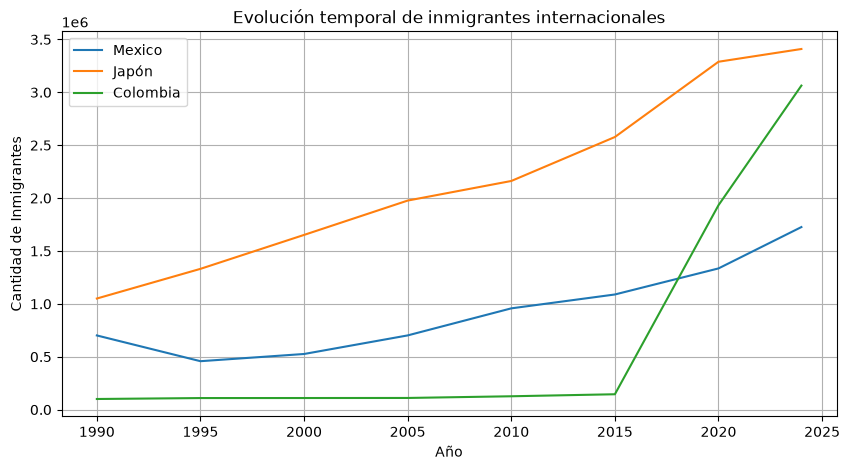

In [ ]:
# Pregunta 8
# Tu codigo aqui
df_mexico = df_paises.loc[df_paises["entity"] == "Mexico"]
df_japon = df_paises.loc[df_paises["entity"] == "Japan"]
df_colombia = df_paises.loc[df_paises["entity"] == "Colombia"]

anios_mx = df_mexico["year"].to_numpy()
valores_mx = df_mexico["valor"].to_numpy()

anios_jp = df_japon["year"].to_numpy()
valores_jp = df_japon["valor"].to_numpy()

anios_co = df_colombia["year"].to_numpy()
valores_co = df_colombia["valor"].to_numpy()

plt.figure(figsize=(10,5))

plt.plot(anios_mx, valores_mx, label="Mexico")
plt.plot(anios_jp, valores_jp, label="Japón")
plt.plot(anios_co, valores_co, label="Colombia")

plt.title("Evolución temporal de inmigrantes internacionales")
plt.xlabel("Año")
plt.ylabel("Cantidad de Inmigrantes")
plt.grid(True)
plt.legend()
plt.show()

**Interpretación:**

*(Escribe aquí tu respuesta)*
Al analizar la evolución temporal en la gráfica, destaca que Japón ha mantenido un crecimiento constante y sostenido, liderando en cantidad de inmigrantes durante casi todo el periodo. México muestra una tendencia al alza mucho más moderada y gradual desde el año 2000 tras una leve caída inicial. Sin embargo, el comportamiento más drástico es el de Colombia, que se mantuvo con cifras muy bajas hasta 2015, momento en el que registra un disparo exponencial que incluso supera a México en la actualidad.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

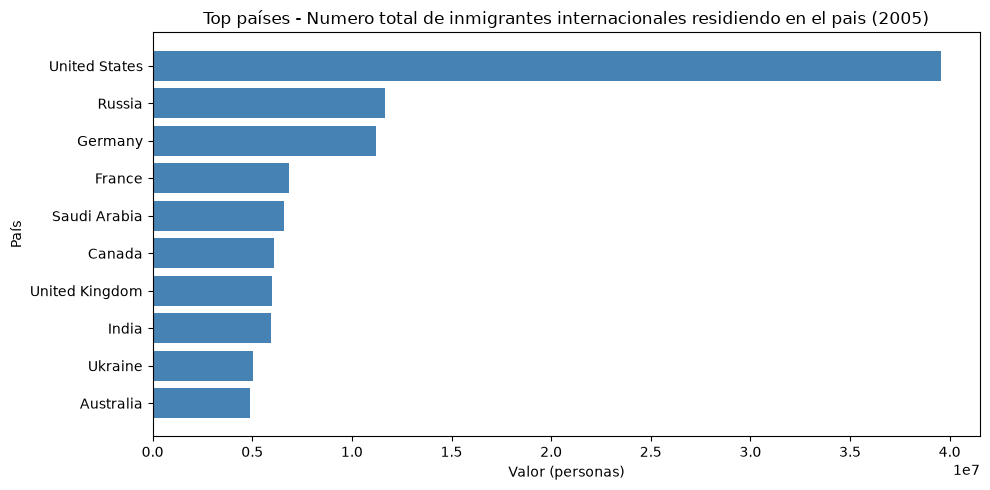

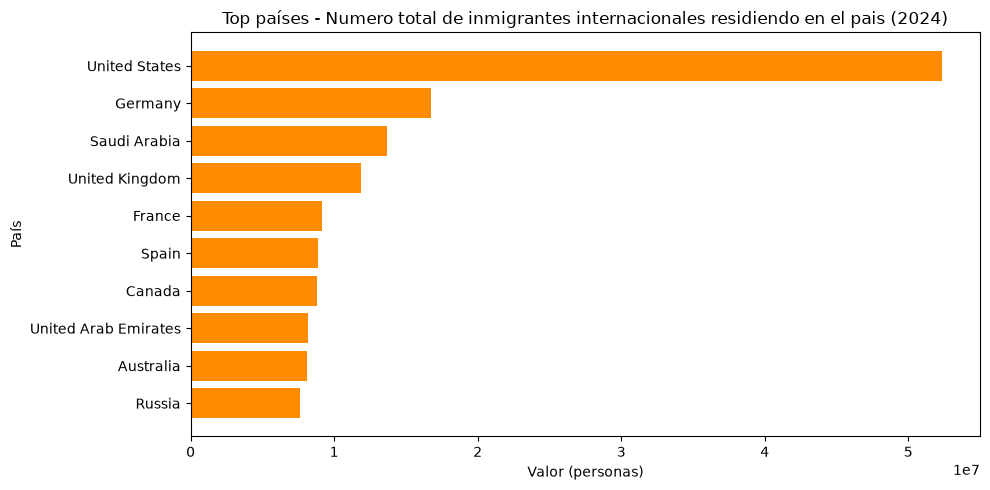

In [ ]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_nacimiento = 2005

top_nacimiento = (
    df_paises[df_paises['year'] == anio_nacimiento]
    .sort_values('valor', ascending=False)
    .head(10)
)

# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top_nacimiento['entity'], top_nacimiento['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_nacimiento})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()

anio_evaluado = 2024

top_2023 = (
    df_paises[df_paises['year'] == anio_evaluado]
    .sort_values('valor', ascending=False)
    .head(10)
)

# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top_2023['entity'], top_2023['valor'], color='darkorange') # Cambiamos color para distinguirla

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_evaluado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()

**Interpretación:**

*(Escribe aquí tu respuesta)*

Al comparar el top 10 entre 2005 y 2024, Estados Unidos se mantiene como el líder indiscutible aumentando aún más su enorme ventaja en la recepción de inmigrantes. Los principales movimientos muestran cómo Alemania, Arabia Saudita y el Reino Unido escalaron varias posiciones para estar en los primeros lugares, a la par que ingresaron nuevos destinos como España y Emiratos Árabes Unidos. En contraste, Rusia decayo  del segundo al décimo lugar, mientras que India y Ucrania salieron definitivamente del ranking, evidenciando que los flujos migratorios se han redirigido fuertemente hacia las grandes potencias europeas y petroleras de Medio Oriente durante las últimas dos décadas.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*(Escribe aquí tu conclusión)*
Al analizar este dataset, comprobé que los flujos migratorios se concentran abrumadoramente en grandes potencias como Estados Unidos y Alemania, mientras que países como México y Colombia muestran un crecimiento acelerado como destinos emergentes. La principal limitación de la información es que presenta valores absolutos sin normalizar, lo que favorece visualmente a los países más grandes y distorsiona la proporción real de inmigrantes respecto a la población local, además de tener datos faltantes en las regiones agrupadas.


## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
